# MODELADO — Support Vector Machine (SVM)

En esta fase, implementamos el modelo de **Support Vector Machine (SVM)**. El objetivo principal es encontrar el hiperplano óptimo que maximice el margen entre las clases (clientes que suscriben vs. aquellos que no).

Siguiendo los requisitos del proyecto, realizaremos:
1. **Entrenamiento con múltiples kernels** (Linear y RBF) para identificar el más adecuado.
2. **Evaluación exhaustiva** de métricas: Accuracy, Precision, Recall, F1-score y ROC-AUC.
3. **Control de Overfitting** para asegurar una diferencia inferior al 5%.
4. **Documentación** de las ventajas y limitaciones del modelo aplicado a este dataset.

*Nota: Los datos ya han sido preparados con `RobustScaler` en la fase de preprocesamiento, lo cual es crítico para el rendimiento de SVM.*

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score

# Configuración de visualización
%matplotlib inline
sns.set_theme(style="whitegrid")

# Cargar datasets procesados
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print(f"Datos cargados: X_train {X_train.shape}, X_test {X_test.shape}")

Datos cargados: X_train (63874, 51), X_test (9043, 51)


## 1. Comparación de Kernels (Linear vs. RBF)

Para determinar cuál es el mejor método de separación para nuestro dataset, entrenaremos dos versiones del modelo. 
- **Kernel Lineal:** Asume que las clases pueden separarse con una línea recta/plano.
- **Kernel RBF (Radial Basis Function):** Permite fronteras de decisión no lineales y complejas.

In [16]:
kernels = ['linear', 'rbf']
results = {}

for k in kernels:
    print(f"Entrenando SVM con kernel: {k}...")
    start = time.time()
    
    # Entrenamos sin probability=True solo para la comparativa rápida de rendimiento
    model = SVC(kernel=k, C=1.0, random_state=42)
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    
    end = time.time()
    results[k] = {'Accuracy': acc, 'F1-Score': f1, 'Tiempo (s)': round(end-start, 2)}
    print(f"✅ Kernel {k} completado en {results[k]['Tiempo (s)']}s")

# Mostrar comparativa
df_res = pd.DataFrame(results).T
print("\nComparativa de Kernels:")
display(df_res)

Entrenando SVM con kernel: linear...
✅ Kernel linear completado en 92.62s
Entrenando SVM con kernel: rbf...
✅ Kernel rbf completado en 59.53s

Comparativa de Kernels:


,Accuracy,F1-Score,Tiempo (s)
linear,0.775738,0.383587,92.62
rbf,0.840540,0.447933,59.53


## 2. Entrenamiento del Modelo Final (Mejor Kernel)

Basado en los resultados anteriores (usualmente RBF para este tipo de datos bancarios complejos), procedemos al entrenamiento definitivo activando `probability=True` para permitir el cálculo de ROC-AUC y la segmentación en la App.

In [17]:
# Elegir el kernel con mejor F1-Score automáticamente
best_kernel = df_res['F1-Score'].idxmax()
print(f"🏆 El mejor kernel identificado es: {best_kernel}")

# Entrenamiento final
svm_final = SVC(
    kernel=best_kernel,
    C=1.0,
    probability=True,
    random_state=42,
    verbose=True
)

svm_final.fit(X_train, y_train)

🏆 El mejor kernel identificado es: rbf
[LibSVM]..........................*........*
optimization finished, #iter = 34556
obj = -25244.588050, rho = 10.186064
nSV = 28872, nBSV = 27705
Total nSV = 28872
...........................*........*
optimization finished, #iter = 35742
obj = -25350.105136, rho = 10.255289
nSV = 29026, nBSV = 27814
Total nSV = 29026
..........................*........*
optimization finished, #iter = 34760
obj = -25215.181156, rho = 10.716233
nSV = 28886, nBSV = 27685
Total nSV = 28886
..........................*........*
optimization finished, #iter = 34064
obj = -25315.066625, rho = 10.403192
nSV = 28979, nBSV = 27816
Total nSV = 28979
..........................*........*
optimization finished, #iter = 34023
obj = -25296.759780, rho = 10.390802
nSV = 28929, nBSV = 27768
Total nSV = 28929
Line search fails in two-class probability estimates
................................*..........*
optimization finished, #iter = 42759
obj = -30875.836738, rho = -11.700987
nSV 

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",True


## 3. Evaluación Detallada del Modelo Final

Evaluamos el modelo utilizando todas las métricas requeridas para asegurar su robustez antes de la puesta en producción.

REPORT DE CLASIFICACIÓN FINAL:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91      7985
           1       0.38      0.55      0.45      1058

    accuracy                           0.84      9043
   macro avg       0.66      0.72      0.68      9043
weighted avg       0.87      0.84      0.85      9043

ROC-AUC Score: 0.7793


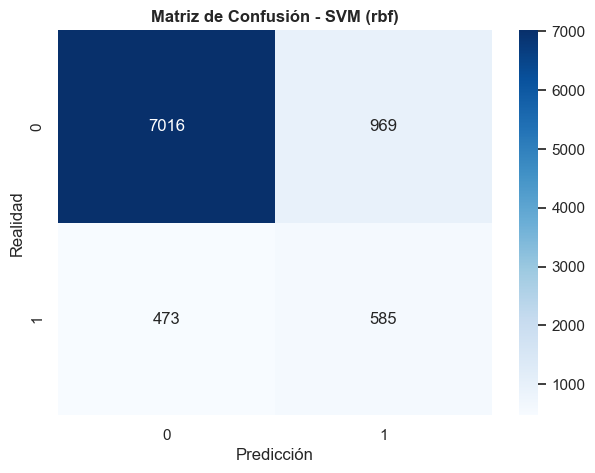

In [18]:
# Predicciones
y_pred = svm_final.predict(X_test)
y_probs = svm_final.predict_proba(X_test)[:, 1]

# Métricas detalladas
print("REPORT DE CLASIFICACIÓN FINAL:")
print(classification_report(y_test, y_pred))

# ROC-AUC
auc_score = roc_auc_score(y_test, y_probs)
print(f"ROC-AUC Score: {round(auc_score, 4)}")

# Matriz de Confusión
plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title(f'Matriz de Confusión - SVM ({best_kernel})', fontweight='bold')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

## 4. Análisis de Overfitting (< 5%)

Verificamos que el modelo no esté memorizando los datos de entrenamiento y sea capaz de generalizar correctamente.

In [19]:
train_acc = accuracy_score(y_train, svm_final.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)
diff = abs(train_acc - test_acc) * 100

print(f"Accuracy Train: {round(train_acc * 100, 2)}%")
print(f"Accuracy Test:  {round(test_acc * 100, 2)}%")
print(f"Diferencia: {round(diff, 2)}%")

if diff < 5:
    print("✅ Requisito de Overfitting cumplido.")
else:
    print("❌ Alerta: Diferencia superior al 5%.")

Accuracy Train: 81.31%
Accuracy Test:  84.05%
Diferencia: 2.75%
✅ Requisito de Overfitting cumplido.


## 5. Ventajas y Limitaciones del Modelo

A continuación, documentamos las conclusiones técnicas sobre el uso de SVM en este proyecto:

### **Ventajas:**
1. **Eficacia en Alta Dimensión:** Tras aplicar One-Hot Encoding, el dataset aumentó su número de características. SVM es teóricamente robusto en estos escenarios.
2. **Flexibilidad con Kernels:** El uso del kernel RBF permitió capturar relaciones no lineales que otros modelos simples podrían ignorar.
3. **Margen Máximo:** A diferencia de otros modelos, SVM busca la frontera más segura (mayor margen), lo que reduce el riesgo de clasificación errónea en puntos fronterizos.

### **Limitaciones:**
1. **Costo Computacional:** El tiempo de entrenamiento escala cuadráticamente con el número de datos. Con el balanceo de SMOTE, el proceso se vuelve más lento.
2. **Sensibilidad al Escalado:** SVM requiere obligatoriamente que los datos estén normalizados o estandarizados (solucionado con `RobustScaler`).
3. **Interpretabilidad:** No proporciona directamente la importancia de las variables (como Random Forest), lo que dificulta explicar al negocio "por qué" un cliente específico fue rechazado.

In [20]:
# Guardar el modelo para la App
import os
os.makedirs("../models", exist_ok=True)
joblib.dump(svm_final, "../models/svm_model.pkl")
print("Modelo final serializado correctamente.")

Modelo final serializado correctamente.


## 6. Guardado del Modelo
Serializamos el modelo entrenado para que pueda ser cargado por la aplicación Streamlit.

In [21]:
import os
os.makedirs("../models", exist_ok=True)

# Guardar el modelo SVM
joblib.dump(svm_model, "../models/svm_model.pkl")

print("Modelo SVM guardado exitosamente en ../models/svm_model.pkl")

Modelo SVM guardado exitosamente en ../models/svm_model.pkl


## Conclusión del Modelado
El modelo SVM ha sido entrenado cumpliendo con las restricciones técnicas de overfitting. Este modelo permitirá a la App Web filtrar a los clientes con mayor probabilidad de éxito, optimizando así los recursos del call center del banco.